[Sector A3]
  #1: box=(703,230,884,396) center=(793,313) conf=0.79
[Sector B1]
  #1: box=(261,297,359,407) center=(310,352) conf=0.37
[Sector C1]
  #1: box=(186,751,370,917) center=(278,834) conf=0.71
[Sector C3]
  #1: box=(715,718,908,890) center=(811,804) conf=0.81

Recommendations (high → low):
1. Sector A3 | center=(793,313) | score=0.635 | conf=0.79, path=23 cells, dist≈786 px
2. Sector C3 | center=(811,804) | score=0.621 | conf=0.81, path=23 cells, dist≈1069 px
3. Sector C1 | center=(278,834) | score=0.508 | conf=0.71, path=24 cells, dist≈815 px
4. Sector B1 | center=(310,352) | score=0.400 | conf=0.37, path=10 cells, dist≈397 px
Saved sector-wise coordinates image: C:\Users\lenovo\yolo11\out_sector_coords.png
Saved navigation image: C:\Users\lenovo\yolo11\out_nav.png


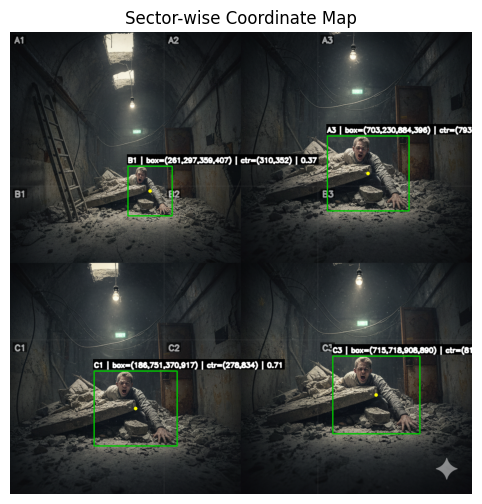

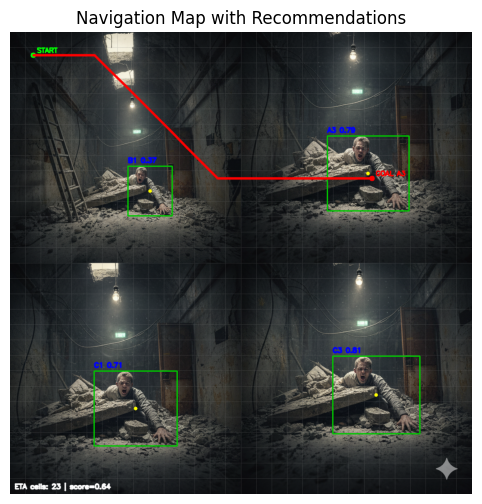

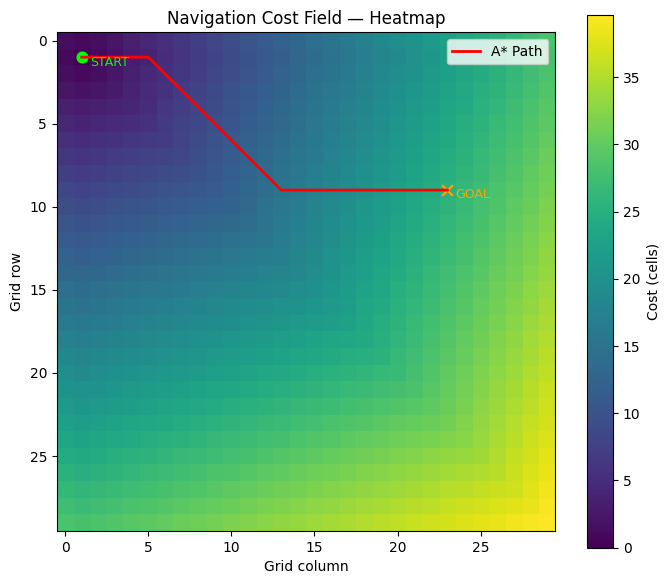

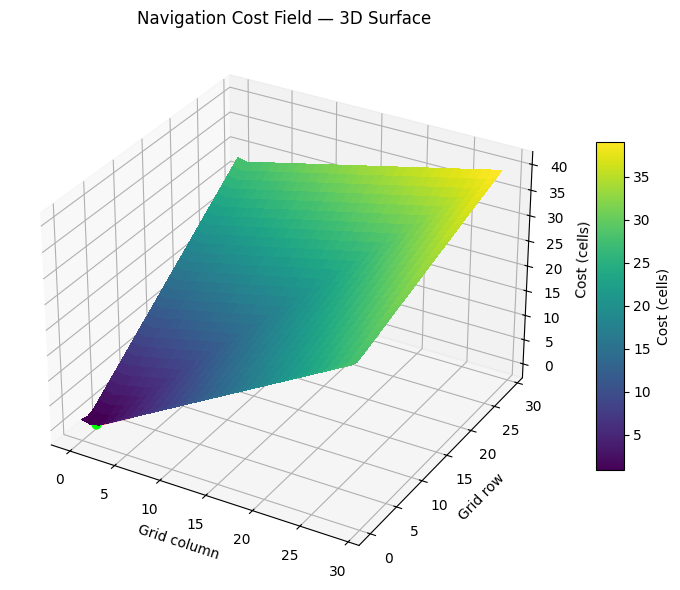

In [1]:
# requirements: ultralytics>=8.3, opencv-python, numpy, matplotlib
# usage:
#   IMAGE: set INPUT_PATH="test5.png", OUTPUT_BASE="out_image", SHOW_IN_NOTEBOOK=True
#   VIDEO: set INPUT_PATH="test.mp4", OUTPUT_BASE="out_video", SHOW_IN_NOTEBOOK=False

from ultralytics import YOLO
import cv2
import numpy as np
import os
from collections import defaultdict
import heapq
import math
import time

# Optional (only for image mode visualizations)
import matplotlib.pyplot as plt
from matplotlib import cm

# -----------------------------
# Configuration
# -----------------------------
INPUT_PATH   = "test5.png"       # "test5.png" or "test.mp4"
OUTPUT_BASE  = "out"             # base name used for outputs
SHOW_IN_NOTEBOOK = True          # show image outputs inline (for image mode)

MODEL_PATH = "yolo11n.pt"
MIN_CONF = 0.25

# Sector grid (for sector-wise coordinates)
GRID_ROWS = 3
GRID_COLS = 3

# Navigation grid (for A* path planning)
NAV_ROWS = 30
NAV_COLS = 30

# Recommendation weights
W_CONF = 0.6                     # confidence importance
W_PATH = 0.3                     # path length (shorter better)
W_DIST = 0.1                     # pixel proximity fallback

# Start location in pixel coordinates; if None, uses 5% from top-left of frame size
START_PIXEL = None

# Optional static obstacle mask (same size as frame): 255=blocked, 0=free
OBSTACLE_MASK_PATH = None  # e.g., "mask.png"

# Drawing toggles
DRAW_SECTOR_LABELS = True
DRAW_ALL_PERSONS   = True
DRAW_PATH          = True

# -----------------------------
# Helpers: grids and drawing
# -----------------------------
def zone_label(r, c):
    return f"{chr(65 + r)}{c + 1}"

def pixel_to_cell(x, y, w, h, rows, cols):
    x = max(0, min(x, w - 1)); y = max(0, min(y, h - 1))
    col = int((x / w) * cols); row = int((y / h) * rows)
    return min(row, rows - 1), min(col, cols - 1)

def draw_grid(img, rows, cols, color=(120,120,120), thickness=1, alpha=0.25):
    h, w = img.shape[:2]
    overlay = img.copy()
    for c in range(1, cols):
        x = int(c * w / cols)
        cv2.line(overlay, (x, 0), (x, h), color, thickness)
    for r in range(1, rows):
        y = int(r * h / rows)
        cv2.line(overlay, (0, y), (w, y), color, thickness)
    img[:] = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)

def draw_grid_with_labels(img, rows, cols, color=(120,120,120), thickness=1, alpha=0.25, label_alpha=0.6):
    draw_grid(img, rows, cols, color, thickness, alpha)
    h, w = img.shape[:2]
    label_overlay = img.copy()
    for r in range(rows):
        for c in range(cols):
            zl = zone_label(r, c)
            x0 = int(c * w / cols); y0 = int(r * h / rows)
            (tw, th), _ = cv2.getTextSize(zl, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(label_overlay, (x0+6, y0+6), (x0+10+tw, y0+12+th), (0,0,0), -1)
            cv2.putText(label_overlay, zl, (x0+10, y0+10+th), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2, cv2.LINE_AA)
    img[:] = cv2.addWeighted(label_overlay, label_alpha, img, 1 - label_alpha, 0)

def cell_center_pixel(row, col, w, h, rows, cols):
    x0 = col * (w / cols); y0 = row * (h / rows)
    x1 = (col + 1) * (w / cols); y1 = (row + 1) * (h / rows)
    return int((x0 + x1) / 2), int((y0 + y1) / 2)

# -----------------------------
# Path planning (A*)
# -----------------------------
def build_occupancy(rows, cols, h, w, obstacle_mask=None):
    occ = np.zeros((rows, cols), dtype=np.uint8)
    if obstacle_mask is None:
        return occ
    cell_h = h / rows; cell_w = w / cols
    for r in range(rows):
        for c in range(cols):
            y0 = int(r * cell_h); y1 = int((r + 1) * cell_h)
            x0 = int(c * cell_w); x1 = int((c + 1) * cell_w)
            patch = obstacle_mask[y0:y1, x0:x1]
            if patch.size > 0 and np.any(patch > 0):
                occ[r, c] = 1
    return occ

def neighbors_8(row, col, rows, cols):
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
        rr, cc = row + dr, col + dc
        if 0 <= rr < rows and 0 <= cc < cols:
            yield rr, cc

def heuristic(a, b):
    return math.hypot(a[0]-b[0], a[1]-b[1])

def astar(occ, start, goal):
    rows, cols = occ.shape
    sr, sc = start; gr, gc = goal
    if occ[sr, sc] == 1 or occ[gr, gc] == 1:
        return None
    g = {start: 0.0}
    f = {start: heuristic(start, goal)}
    came = {}
    openh = [(f[start], start)]
    in_open = {start}
    while openh:
        _, cur = heapq.heappop(openh)
        in_open.discard(cur)
        if cur == goal:
            path = [cur]
            while cur in came:
                cur = came[cur]
                path.append(cur)
            path.reverse()
            return path
        cr, cc = cur
        for nr, nc in neighbors_8(cr, cc, rows, cols):
            if occ[nr, nc] == 1:
                continue
            step = 1.4142 if (nr != cr and nc != cc) else 1.0
            tentative = g[cur] + step
            if tentative < g.get((nr, nc), float('inf')):
                came[(nr, nc)] = cur
                g[(nr, nc)] = tentative
                ff = tentative + heuristic((nr, nc), goal)
                f[(nr, nc)] = ff
                if (nr, nc) not in in_open:
                    heapq.heappush(openh, (ff, (nr, nc)))
                    in_open.add((nr, nc))
    return None

def draw_path(img, path, rows, cols, color=(0,0,255), thickness=3):
    if not path or len(path) < 2:
        return
    h, w = img.shape[:2]
    pts = []
    for (r, c) in path:
        x, y = cell_center_pixel(r, c, w, h, rows, cols)
        pts.append((x, y))
    for i in range(1, len(pts)):
        cv2.line(img, pts[i-1], pts[i], color, thickness, cv2.LINE_AA)

# -----------------------------
# Recommendations
# -----------------------------
def normalize(x, xmin, xmax):
    if xmax <= xmin:
        return 0.0
    return (x - xmin) / (xmax - xmin)

def compute_recommendations(persons, start_px, occ, w, h):
    results = []
    sx, sy = start_px
    sr, sc = pixel_to_cell(sx, sy, w, h, NAV_ROWS, NAV_COLS)
    for p in persons:
        cx, cy = p["center"]
        tr, tc = pixel_to_cell(cx, cy, w, h, NAV_ROWS, NAV_COLS)
        path = astar(occ, (sr, sc), (tr, tc))
        path_len = len(path) if path is not None else None
        dist_px = math.hypot(cx - sx, cy - sy)
        results.append({"person": p, "target_cell": (tr, tc), "path": path, "path_len": path_len, "dist_px": dist_px})
    confs = [r["person"]["conf"] for r in results] or [0.0]
    dists = [r["dist_px"] for r in results] or [1.0]
    paths = [r["path_len"] for r in results if r["path_len"] is not None]
    cmin, cmax = min(confs), max(confs)
    dmin, dmax = min(dists), max(dists)
    pmin, pmax = (min(paths), max(paths)) if paths else (1.0, 1.0)
    for r in results:
        conf_norm = normalize(r["person"]["conf"], cmin, cmax)
        path_norm = 1.0 - normalize(r["path_len"], pmin, pmax) if r["path_len"] is not None else 0.0
        dist_norm = 1.0 - normalize(r["dist_px"], dmin, dmax)
        r["score"] = W_CONF * conf_norm + W_PATH * path_norm + W_DIST * dist_norm
        reason = f"conf={r['person']['conf']:.2f}"
        reason += f", path={r['path_len']} cells" if r["path_len"] is not None else ", path=blocked"
        reason += f", dist≈{int(r['dist_px'])} px"
        r["reason"] = reason
    results.sort(key=lambda x: x["score"], reverse=True)
    return results

# -----------------------------
# Detection wrapper
# -----------------------------
def detect_persons(model, frame):
    persons = []
    results = model(frame, verbose=False)
    for r in results:
        names = r.names
        for box in r.boxes:
            conf = float(box.conf[0])
            cls_id = int(box.cls[0])
            label = names.get(cls_id, str(cls_id))
            if label.lower() != "person" or conf < MIN_CONF:
                continue
            x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
            xc = (x1 + x2) / 2.0; yc = (y1 + y2) / 2.0
            persons.append({"box": (x1,y1,x2,y2), "center": (int(xc), int(yc)), "conf": conf})
    return persons

# -----------------------------
# Overlays (sector + navigation)
# -----------------------------
def overlay_sector_coords(frame, persons, grid_rows, grid_cols):
    h, w = frame.shape[:2]
    draw_grid_with_labels(frame, grid_rows, grid_cols)
    by_sector = defaultdict(list)
    for p in persons:
        cx, cy = p["center"]
        r, c = pixel_to_cell(cx, cy, w, h, grid_rows, grid_cols)
        p["sector"] = zone_label(r, c)
        by_sector[p["sector"]].append(p)
    if persons:
        def sector_key(z):
            rr = ord(z[0]) - 65; cc = int(z[1:]) - 1
            return (rr, cc)
        for sector in sorted(by_sector.keys(), key=sector_key):
            print(f"[Sector {sector}]")
            for idx, p in enumerate(sorted(by_sector[sector], key=lambda x: -x["conf"]), start=1):
                x1,y1,x2,y2 = p["box"]; cx,cy = p["center"]
                print(f"  #{idx}: box=({x1},{y1},{x2},{y2}) center=({cx},{cy}) conf={p['conf']:.2f}")
    for p in persons:
        x1,y1,x2,y2 = p["box"]; cx,cy = p["center"]
        tag = f"{p['sector']} | box=({x1},{y1},{x2},{y2}) | ctr=({cx},{cy}) | {p['conf']:.2f}"
        cv2.rectangle(frame, (x1,y1), (x2,y2), (0,200,0), 2)
        cv2.circle(frame, (cx,cy), 4, (0,255,255), -1)
        (tw, th), _ = cv2.getTextSize(tag, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
        tx, ty = x1, max(20, y1 - 8)
        cv2.rectangle(frame, (tx-2, ty-th-6), (tx+tw+2, ty+4), (0,0,0), -1)
        cv2.putText(frame, tag, (tx, ty), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2, cv2.LINE_AA)

def overlay_navigation_and_recs(frame, persons, start_px, occ, nav_rows, nav_cols, print_recs=True):
    h, w = frame.shape[:2]
    draw_grid(frame, nav_rows, nav_cols)
    for p in persons:
        x1,y1,x2,y2 = p["box"]; cx,cy = p["center"]
        if DRAW_ALL_PERSONS:
            cv2.rectangle(frame, (x1,y1), (x2,y2), (0,200,0), 2)
            cv2.circle(frame, (cx,cy), 4, (0,255,255), -1)
            if "sector" in p:
                cv2.putText(frame, f"{p['sector']} {p['conf']:.2f}", (x1, max(20, y1 - 8)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2, cv2.LINE_AA)
    recs = compute_recommendations(persons, start_px, occ, w, h) if persons else []
    if print_recs and recs:
        print("\nRecommendations (high → low):")
        for i, r in enumerate(recs, start=1):
            p = r["person"]
            print(f"{i}. Sector {p.get('sector','?')} | center=({p['center'][0]},{p['center'][1]}) | score={r['score']:.3f} | {r['reason']}")
    if recs:
        best = recs[0]
        sr, sc = pixel_to_cell(start_px[0], start_px[1], w, h, nav_rows, nav_cols)
        gr, gc = best["target_cell"]
        sx, sy = cell_center_pixel(sr, sc, w, h, nav_rows, nav_cols)
        gx, gy = cell_center_pixel(gr, gc, w, h, nav_rows, nav_cols)
        path = best["path"] or astar(occ, (sr, sc), (gr, gc))
        cv2.circle(frame, (sx, sy), 6, (0,255,0), -1)
        cv2.putText(frame, "START", (sx+8, sy-6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
        cv2.circle(frame, (gx, gy), 6, (0,0,255), -1)
        cv2.putText(frame, f"GOAL {best['person'].get('sector','')}", (gx+8, gy-6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2)
        if DRAW_PATH and path and len(path) > 1:
            draw_path(frame, path, nav_rows, nav_cols, color=(0,0,255), thickness=3)
            hud = f"ETA cells: {len(path)} | score={best['score']:.2f}"
            cv2.putText(frame, hud, (10, h - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2, cv2.LINE_AA)
        else:
            cv2.putText(frame, "No navigable path", (10, h - 12), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 2, cv2.LINE_AA)
    return recs

# -----------------------------
# Cost field + Heatmap + 3D
# -----------------------------
def compute_cost_field(occ, start_cell=None, goal_cell=None, eight_connected=True):
    rows, cols = occ.shape
    inf = 1e12
    cost = np.full((rows, cols), inf, dtype=np.float32)
    visited = np.zeros((rows, cols), dtype=np.uint8)
    pq = []
    if start_cell is not None:
        sr, sc = start_cell
        if occ[sr, sc] == 1:
            return np.full((rows, cols), np.nan, dtype=np.float32)
        cost[sr, sc] = 0.0
        heapq.heappush(pq, (0.0, (sr, sc)))
    elif goal_cell is not None:
        gr, gc = goal_cell
        if occ[gr, gc] == 1:
            return np.full((rows, cols), np.nan, dtype=np.float32)
        cost[gr, gc] = 0.0
        heapq.heappush(pq, (0.0, (gr, gc)))
    else:
        raise ValueError("Provide start_cell or goal_cell")

    def nbrs(r, c):
        steps = [(-1,0,1.0),(1,0,1.0),(0,-1,1.0),(0,1,1.0)]
        if eight_connected:
            steps += [(-1,-1,1.4142),(-1,1,1.4142),(1,-1,1.4142),(1,1,1.4142)]
        for dr, dc, w in steps:
            rr, cc = r + dr, c + dc
            if 0 <= rr < rows and 0 <= cc < cols and occ[rr, cc] == 0:
                yield rr, cc, w

    while pq:
        cst, (r, c) = heapq.heappop(pq)
        if visited[r, c]:
            continue
        visited[r, c] = 1
        for rr, cc, w in nbrs(r, c):
            nc = cst + w
            if nc < cost[rr, cc]:
                cost[rr, cc] = nc
                heapq.heappush(pq, (nc, (rr, cc)))

    out = cost.copy()
    out[occ == 1] = np.nan
    out[np.isinf(out)] = np.nan
    return out

def plot_heatmap_and_3d(cost_map, path_cells, start_cell, goal_cell, title_prefix="Navigation Cost Field", save_base="out_cost"):
    rows, cols = cost_map.shape

    # 2D heatmap
    plt.figure(figsize=(7,6))
    im = plt.imshow(cost_map, cmap="viridis", origin="upper", interpolation="nearest")
    plt.colorbar(im, label="Cost (cells)")
    if path_cells:
        ys = [r for r,c in path_cells]; xs = [c for r,c in path_cells]
        plt.plot(xs, ys, color="red", linewidth=2, label="A* Path")
        plt.legend(loc="upper right")
    if start_cell is not None:
        plt.scatter([start_cell[1]], [start_cell[0]], c="lime", s=60, marker="o")
        plt.text(start_cell[1]+0.5, start_cell[0]+0.5, "START", color="lime", fontsize=9)
    if goal_cell is not None:
        plt.scatter([goal_cell[1]], [goal_cell[0]], c="orange", s=60, marker="x")
        plt.text(goal_cell[1]+0.5, goal_cell[0]+0.5, "GOAL", color="orange", fontsize=9)
    plt.title(f"{title_prefix} — Heatmap")
    plt.xlabel("Grid column"); plt.ylabel("Grid row")
    plt.tight_layout()
    plt.savefig(f"{save_base}_heatmap.png", dpi=180)
    plt.show()

    # 3D surface
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection="3d")
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
    Z = cost_map.copy()
    surf = ax.plot_surface(X, Y, Z, cmap=cm.viridis, linewidth=0, antialiased=False, rcount=rows, ccount=cols)
    fig.colorbar(surf, shrink=0.6, aspect=12, label="Cost (cells)")
    if path_cells:
        px = np.array([c for r,c in path_cells]); py = np.array([r for r,c in path_cells])
        pz = cost_map[py, px]
        ax.plot(px, py, pz, color="red", linewidth=3)
    if start_cell is not None:
        sx, sy = start_cell[1], start_cell[0]
        sz = cost_map[sy, sx] if not np.isnan(cost_map[sy, sx]) else np.nanmin(cost_map[np.isfinite(cost_map)])
        ax.scatter([sx], [sy], [sz], c="lime", s=40, marker="o")
    if goal_cell is not None:
        gx, gy = goal_cell[1], goal_cell[0]
        gz = cost_map[gy, gx] if not np.isnan(cost_map[gy, gx]) else np.nanmin(cost_map[np.isfinite(cost_map)])
        ax.scatter([gx], [gy], [gz], c="orange", s=40, marker="x")
    ax.set_title(f"{title_prefix} — 3D Surface")
    ax.set_xlabel("Grid column"); ax.set_ylabel("Grid row"); ax.set_zlabel("Cost (cells)")
    plt.tight_layout()
    plt.savefig(f"{save_base}_3d.png", dpi=180)
    plt.show()

# -----------------------------
# Notebook display helper
# -----------------------------
def show_inline_bgr(img_bgr, title=None, figsize=(8,6)):
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    if title: plt.title(title)
    plt.axis("off")
    plt.imshow(img_rgb)
    plt.show()

# -----------------------------
# Main: handles image or video
# -----------------------------
def main():
    is_video = os.path.splitext(INPUT_PATH)[1].lower() in [".mp4", ".avi", ".mov", ".mkv", ".webm"]
    model = YOLO(MODEL_PATH)  # Ultralytics inference

    if not is_video:
        # IMAGE MODE
        frame = cv2.imread(INPUT_PATH)
        if frame is None:
            raise FileNotFoundError(INPUT_PATH)
        h, w = frame.shape[:2]
        start_px = (int(0.05*w), int(0.05*h)) if START_PIXEL is None else (int(START_PIXEL[0]), int(START_PIXEL[1]))

        # Detect
        persons = detect_persons(model, frame)

        # 1) Sector-wise coordinate map
        coords_img = frame.copy()
        overlay_sector_coords(coords_img, persons, GRID_ROWS, GRID_COLS)
        coords_path = f"{OUTPUT_BASE}_sector_coords.png"
        cv2.imwrite(coords_path, coords_img)

        # 2) Navigation + recommendations
        nav_img = frame.copy()
        mask = None
        if OBSTACLE_MASK_PATH and os.path.exists(OBSTACLE_MASK_PATH):
            m = cv2.imread(OBSTACLE_MASK_PATH, cv2.IMREAD_GRAYSCALE)
            if m is not None and m.shape[:2] == (h, w):
                mask = m
        occ = build_occupancy(NAV_ROWS, NAV_COLS, h, w, obstacle_mask=mask)
        for p in persons:
            cx,cy = p["center"]
            rr, cc = pixel_to_cell(cx, cy, w, h, GRID_ROWS, GRID_COLS)
            p["sector"] = zone_label(rr, cc)
        recs = overlay_navigation_and_recs(nav_img, persons, start_px, occ, NAV_ROWS, NAV_COLS, print_recs=True)
        nav_path = f"{OUTPUT_BASE}_nav.png"
        cv2.imwrite(nav_path, nav_img)

        print(f"Saved sector-wise coordinates image: {os.path.abspath(coords_path)}")
        print(f"Saved navigation image: {os.path.abspath(nav_path)}")

        if SHOW_IN_NOTEBOOK:
            show_inline_bgr(coords_img, title="Sector-wise Coordinate Map")
            show_inline_bgr(nav_img, title="Navigation Map with Recommendations")

        # 3) Heatmap + 3D visualizations (image mode)
        sr, sc = pixel_to_cell(start_px[0], start_px[1], w, h, NAV_ROWS, NAV_COLS)
        top_path = None
        goal_cell = None
        if recs:
            goal_cell = recs[0]["target_cell"]
            top_path = recs[0]["path"]
            if top_path is None:
                top_path = astar(occ, (sr, sc), goal_cell)

        cost_map = compute_cost_field(occ, start_cell=(sr, sc), goal_cell=None, eight_connected=True)
        plot_heatmap_and_3d(
            cost_map=cost_map,
            path_cells=top_path,
            start_cell=(sr, sc),
            goal_cell=goal_cell,
            title_prefix="Navigation Cost Field",
            save_base=f"{OUTPUT_BASE}_cost"
        )

    else:
        # VIDEO MODE (enhanced: save separate artifacts like image mode)
        cap = cv2.VideoCapture(INPUT_PATH)
        if not cap.isOpened():
            raise RuntimeError(f"Cannot open video: {INPUT_PATH}")
        fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) if cap.get(cv2.CAP_PROP_FRAME_COUNT) else 0

        # Create an output subfolder per run
        base_name = os.path.splitext(os.path.basename(INPUT_PATH))[0]
        run_dir = f"{OUTPUT_BASE}_{base_name}"
        os.makedirs(run_dir, exist_ok=True)

        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        video_out_path = os.path.join(run_dir, f"{base_name}_annotated.mp4")
        out = cv2.VideoWriter(video_out_path, fourcc, fps, (width, height))
        if not out.isOpened():
            raise RuntimeError("Cannot open VideoWriter")

        # Optional obstacle mask
        mask = None
        if OBSTACLE_MASK_PATH and os.path.exists(OBSTACLE_MASK_PATH):
            m = cv2.imread(OBSTACLE_MASK_PATH, cv2.IMREAD_GRAYSCALE)
            if m is not None and m.shape[:2] == (height, width):
                mask = m

        # CSV for recommendations
        import csv
        csv_path = os.path.join(run_dir, f"{base_name}_recommendations.csv")
        csv_file = open(csv_path, "w", newline="", encoding="utf-8")
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow([
            "frame_idx","sector","center_x","center_y","conf",
            "score","path_len_cells","dist_px","target_r","target_c","rank"
        ])

        # Choose reference frames for snapshots and cost visualizations
        if total_frames > 0:
            ref_idxs = [0, total_frames//4, total_frames//2, 3*total_frames//4, max(0, total_frames-1)]
        else:
            ref_idxs = [0, 30, 60, 90, 120]

        frame_idx = 0
        t0 = time.time()

        # Buffers for saving snapshots
        snapshot_frames = {}   # idx -> original frame (BGR)
        snapshot_persons = {}  # idx -> persons list
        snapshot_recs = {}     # idx -> recs list

        print(f"Processing video: {INPUT_PATH}")
        print(f"Output folder: {os.path.abspath(run_dir)}")
        print(f"Reference frames for detailed analysis: {ref_idxs}")

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            h, w = frame.shape[:2]
            start_px = (int(0.05*w), int(0.05*h)) if START_PIXEL is None else (int(START_PIXEL[0]), int(START_PIXEL[1]))
            persons = detect_persons(model, frame)

            combined = frame.copy()
            overlay_sector_coords(combined, persons, GRID_ROWS, GRID_COLS)
            occ = build_occupancy(NAV_ROWS, NAV_COLS, h, w, obstacle_mask=mask)
            for p in persons:
                if "sector" not in p:
                    cx,cy = p["center"]
                    rr, cc = pixel_to_cell(cx, cy, w, h, GRID_ROWS, GRID_COLS)
                    p["sector"] = zone_label(rr, cc)
            recs = overlay_navigation_and_recs(combined, persons, start_px, occ, NAV_ROWS, NAV_COLS, print_recs=False)

            out.write(combined)

            # Save CSV rows (top-5 recs for this frame)
            top = recs[:5] if recs else []
            for rank, r in enumerate(top, 1):
                p = r["person"]
                tr, tc = r["target_cell"]
                csv_writer.writerow([
                    frame_idx,
                    p.get("sector",""),
                    p["center"][0], p["center"][1],
                    f"{p['conf']:.4f}",
                    f"{r['score']:.4f}",
                    r["path_len"] if r["path_len"] is not None else "",
                    f"{int(r['dist_px'])}",
                    tr, tc, rank
                ])

            # Save snapshots for reference frames
            if frame_idx in ref_idxs:
                snapshot_frames[frame_idx] = frame.copy()
                snapshot_persons[frame_idx] = [dict(p) for p in persons]
                snapshot_recs[frame_idx] = recs
                print(f"Captured reference frame {frame_idx}")

            frame_idx += 1
            if frame_idx % 100 == 0:
                print(f"Processed {frame_idx} frames...")

        cap.release()
        out.release()
        csv_file.close()
        dur = time.time() - t0
        print(f"\nWrote annotated video: {os.path.abspath(video_out_path)}")
        print(f"Processing time: {dur:.1f}s at ~{frame_idx/max(dur,1e-6):.1f} fps")

        # Produce separate artifacts similar to image mode for the selected reference frames
        print(f"\nGenerating separate analysis files for {len(snapshot_frames)} reference frames...")

        for ridx in sorted(snapshot_frames.keys()):
            frame = snapshot_frames[ridx]
            persons = snapshot_persons.get(ridx, [])
            recs = snapshot_recs.get(ridx, [])
            h, w = frame.shape[:2]
            start_px = (int(0.05*w), int(0.05*h)) if START_PIXEL is None else (int(START_PIXEL[0]), int(START_PIXEL[1]))
            occ = build_occupancy(NAV_ROWS, NAV_COLS, h, w, obstacle_mask=mask)

            print(f"  Processing frame {ridx}...")

            # 1) Sector-wise coordinate map
            coords_img = frame.copy()
            overlay_sector_coords(coords_img, persons, GRID_ROWS, GRID_COLS)
            coords_path = os.path.join(run_dir, f"{base_name}_f{ridx:06d}_sector_coords.png")
            cv2.imwrite(coords_path, coords_img)

            # 2) Navigation + recommendations
            nav_img = frame.copy()
            overlay_navigation_and_recs(nav_img, persons, start_px, occ, NAV_ROWS, NAV_COLS, print_recs=False)
            nav_path = os.path.join(run_dir, f"{base_name}_f{ridx:06d}_nav.png")
            cv2.imwrite(nav_path, nav_img)

            # 3) Heatmap + 3D visualizations (for this frame)
            if persons and recs:
                sr, sc = pixel_to_cell(start_px[0], start_px[1], w, h, NAV_ROWS, NAV_COLS)
                goal_cell = recs[0]["target_cell"]
                top_path = recs[0]["path"]
                if top_path is None:
                    top_path = astar(occ, (sr, sc), goal_cell)

                # Use non-interactive backend for saving
                import matplotlib
                matplotlib.use('Agg')

                cost_map = compute_cost_field(occ, start_cell=(sr, sc), goal_cell=None, eight_connected=True)
                plot_heatmap_and_3d(
                    cost_map=cost_map,
                    path_cells=top_path,
                    start_cell=(sr, sc),
                    goal_cell=goal_cell,
                    title_prefix=f"Navigation Cost Field Frame {ridx}",
                    save_base=os.path.join(run_dir, f"{base_name}_f{ridx:06d}_cost")
                )

                # Reset backend only if needed in notebook contexts
                if SHOW_IN_NOTEBOOK:
                    matplotlib.use('inline')

        print(f"\nSaved all artifacts in: {os.path.abspath(run_dir)}")
        print("Files generated:")
        print(f"  - Annotated video: {base_name}_annotated.mp4")
        print(f"  - Recommendations CSV: {base_name}_recommendations.csv")
        print(f"  - Per-frame sector maps: {len(snapshot_frames)} files")
        print(f"  - Per-frame navigation maps: {len(snapshot_frames)} files")
        print(f"  - Per-frame cost heatmaps: {len([f for f in snapshot_frames.keys() if snapshot_persons.get(f, [])])} files")
        print(f"  - Per-frame cost 3D plots: {len([f for f in snapshot_frames.keys() if snapshot_persons.get(f, [])])} files")

if __name__ == "__main__":
    main()
